In [1]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from ydata_profiling import ProfileReport
from sklearn.pipeline import Pipeline
import optuna
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [2]:
data_dir = "../data"
train_data = os.path.join(data_dir, "train.csv")
test_data = os.path.join(data_dir, "test.csv")
titanic_train_df = pd.read_csv(train_data)
titanic_test_df = pd.read_csv(test_data)

In [3]:
titanic_train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
titanic_train_df.head().style.background_gradient(cmap='Blues').hide(axis="index")


PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.250000,nan,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.000000,1,0,PC 17599,71.283300,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.925000,nan,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.100000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.050000,nan,S


In [5]:
titanic_train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
titanic_train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
titanic_train_df.shape

(891, 12)

In [8]:
titanic_train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [9]:
titanic_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [10]:
exclude = ["PassengerId", "Name", "Age", "Ticket", "Fare", "Cabin"]
for curr_col in titanic_train_df.columns:
    if not curr_col in exclude:
        print(f"{curr_col} unique values: {titanic_train_df[curr_col].unique()}")

Survived unique values: [0 1]
Pclass unique values: [3 1 2]
Sex unique values: ['male' 'female']
SibSp unique values: [1 0 3 4 2 5 8]
Parch unique values: [0 1 2 5 3 4 6]
Embarked unique values: ['S' 'C' 'Q' nan]


In [11]:
missing = titanic_train_df.isna().mean().sort_values(ascending=False)
missing[missing > 0]

Cabin       0.771044
Age         0.198653
Embarked    0.002245
dtype: float64

In [12]:
# Cabin has highest nan values
titanic_train_df["Cabin"]

0       NaN
1       C85
2       NaN
3      C123
4       NaN
       ... 
886     NaN
887     B42
888     NaN
889    C148
890     NaN
Name: Cabin, Length: 891, dtype: object

<Axes: >

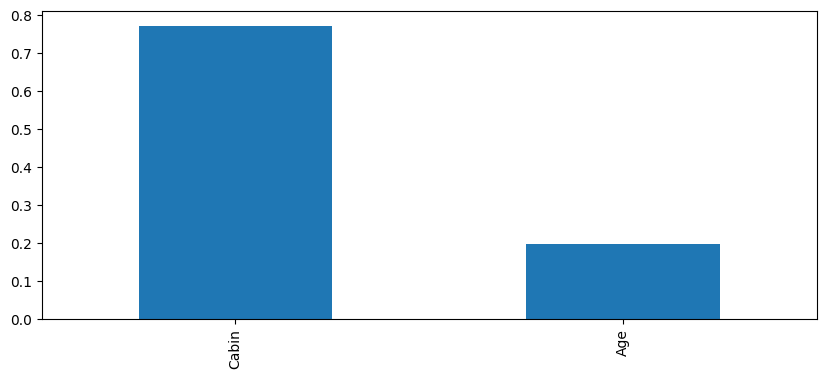

In [13]:
missing[missing > 0.1].plot(kind="bar", figsize=(10,4))

After plotting the graph Cabin has the null values
followed by Age and Embarked

In [14]:
numeric_features = titanic_train_df.select_dtypes(include=['number']).columns.tolist()
categorical_features = titanic_train_df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

print(f"We have {len(numeric_features)} numerical features: {numeric_features}")
print(f"\nWe have {len(categorical_features)} categorical features: {categorical_features}")

We have 7 numerical features: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

We have 5 categorical features: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


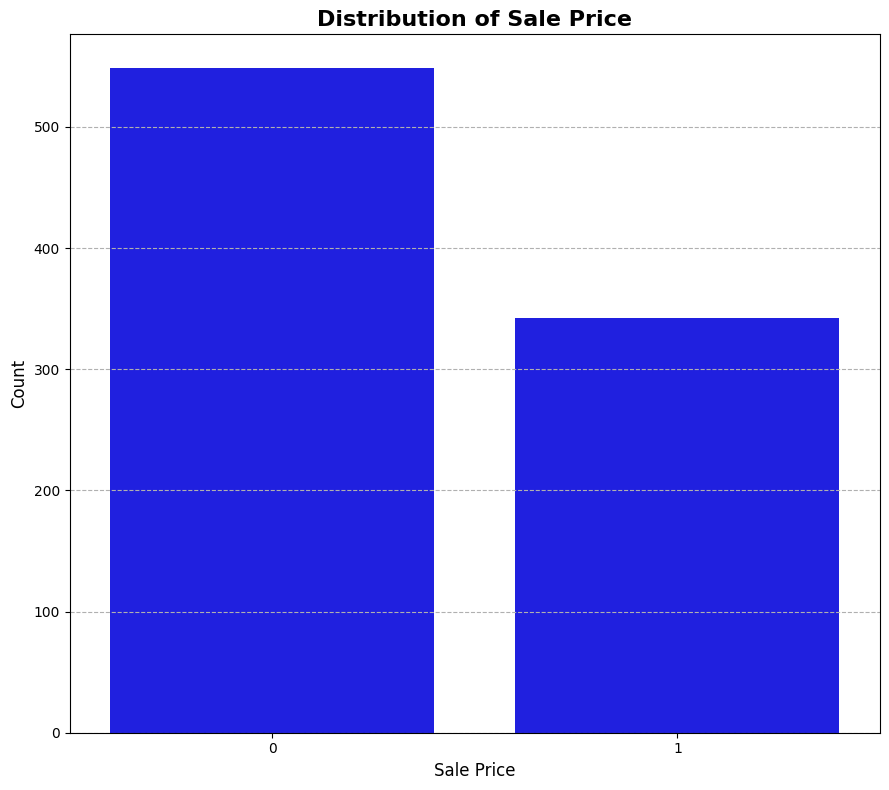

In [15]:
#Sale Price Distrbution.

plt.figure(figsize=(9, 8))

sns.countplot(
    x = "Survived",
    color='blue',
    data = titanic_train_df
)

plt.title("Distribution of Sale Price", fontsize=16, weight="bold")
plt.xlabel("Sale Price", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.grid(axis='y', linestyle='--', )
plt.tight_layout()
plt.show()

In [16]:
# --- Train Dataset Report ---
ProfileReport(titanic_train_df, title='Train Dataset', minimal=True, progress_bar=False, samples=None, correlations=None, interactions=None, explorative=True,  notebook={'iframe':{'height': '600px'}}, html={'style':{'primary_color': '#219EBC'}}, missing_diagrams={'heatmap': False, 'dendrogram': False}).to_notebook_iframe()

100%|██████████| 12/12 [00:00<00:00, 624.64it/s]


In [17]:
def concat_df(train_data, test_data):
    all_data = pd.concat([train_data, test_data], sort=True).reset_index(drop=True)
    return all_data, len(train_data)

def divide_df(all_data, train_len):
    train = all_data.iloc[:train_len]
    test = all_data.iloc[train_len:].drop(['Survived'], axis=1)
    return train, test

In [18]:
all_data, train_len = concat_df(titanic_train_df, titanic_test_df)

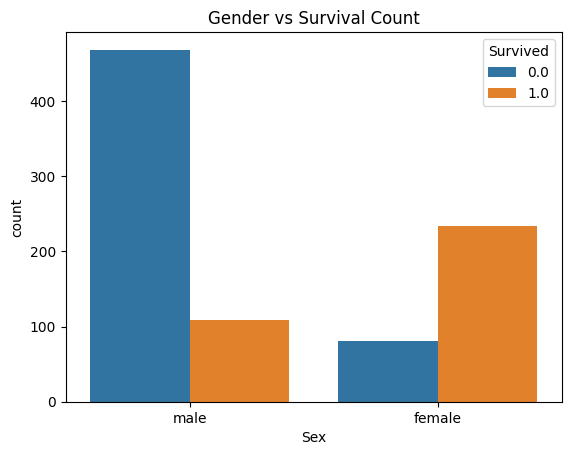

In [19]:
plt.figure()
sns.countplot(data=all_data, x="Sex", hue="Survived")
plt.title("Gender vs Survival Count")
plt.show()

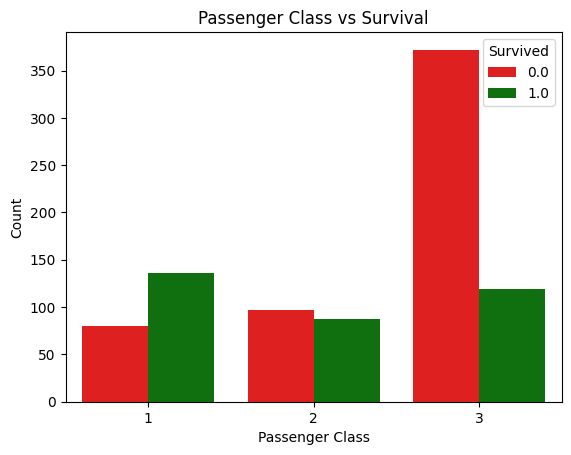

In [20]:
plt.figure()
sns.countplot(data= all_data, x="Pclass", hue="Survived",
              palette={0: "red", 1: "green"})
plt.title("Passenger Class vs Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()

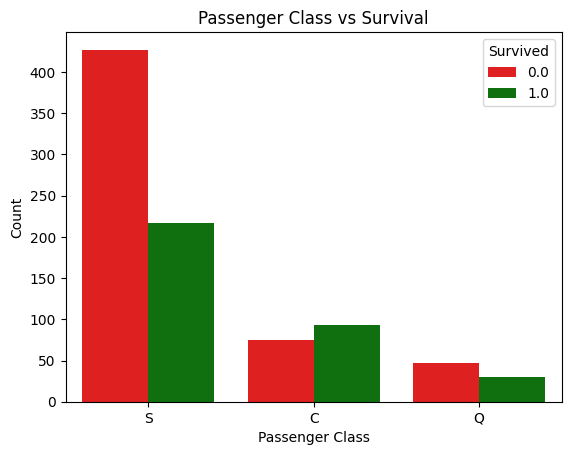

In [21]:
plt.figure()
sns.countplot(data= all_data, x="Embarked", hue="Survived",
              palette={0: "red", 1: "green"})
plt.title("Passenger Class vs Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()

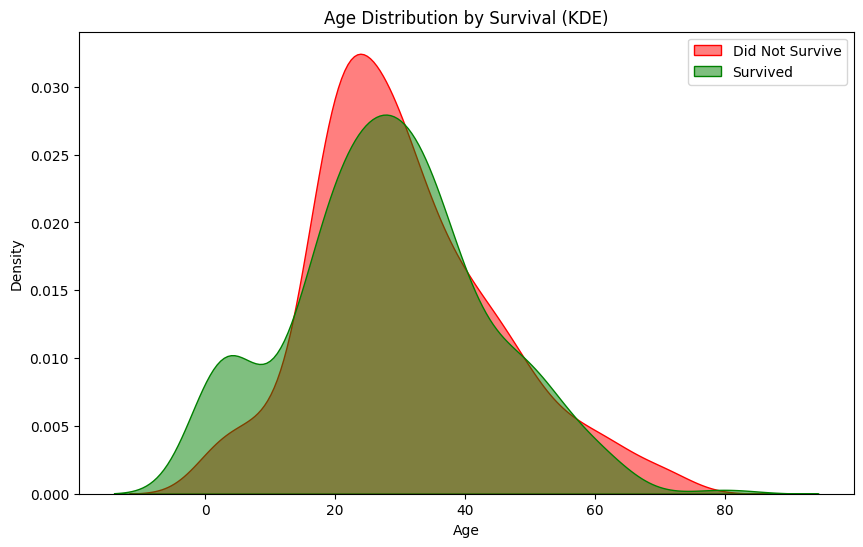

In [22]:
plt.figure(figsize=(10,6))

# KDE for non-survivors
sns.kdeplot(all_data[all_data['Survived'] == 0]['Age'].dropna(), 
            label='Did Not Survive', color='red', fill=True, alpha=0.5)

# KDE for survivors
sns.kdeplot(all_data[all_data['Survived'] == 1]['Age'].dropna(), 
            label='Survived', color='green', fill=True, alpha=0.5)

plt.title("Age Distribution by Survival (KDE)")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend()
plt.show()

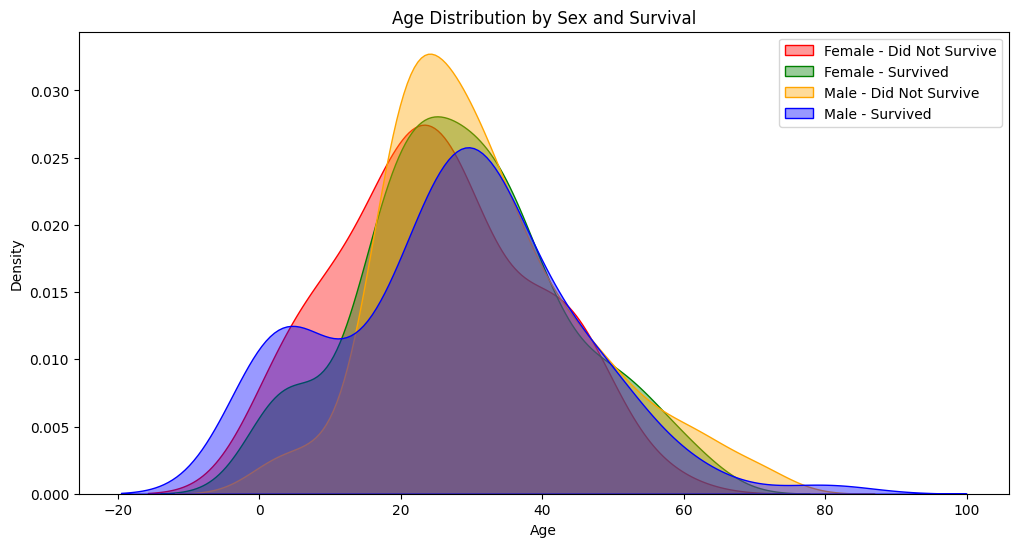

In [23]:
plt.figure(figsize=(12,6))

# Females
sns.kdeplot(all_data[(all_data['Survived']==0) & (all_data['Sex']=='female')]['Age'].dropna(),
            label='Female - Did Not Survive', color='red', fill=True, alpha=0.4)
sns.kdeplot(all_data[(all_data['Survived']==1) & (all_data['Sex']=='female')]['Age'].dropna(),
            label='Female - Survived', color='green', fill=True, alpha=0.4)

# Males
sns.kdeplot(all_data[(all_data['Survived']==0) & (all_data['Sex']=='male')]['Age'].dropna(),
            label='Male - Did Not Survive', color='orange', fill=True, alpha=0.4)
sns.kdeplot(all_data[(all_data['Survived']==1) & (all_data['Sex']=='male')]['Age'].dropna(),
            label='Male - Survived', color='blue', fill=True, alpha=0.4)

plt.title("Age Distribution by Sex and Survival")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend()
plt.show()

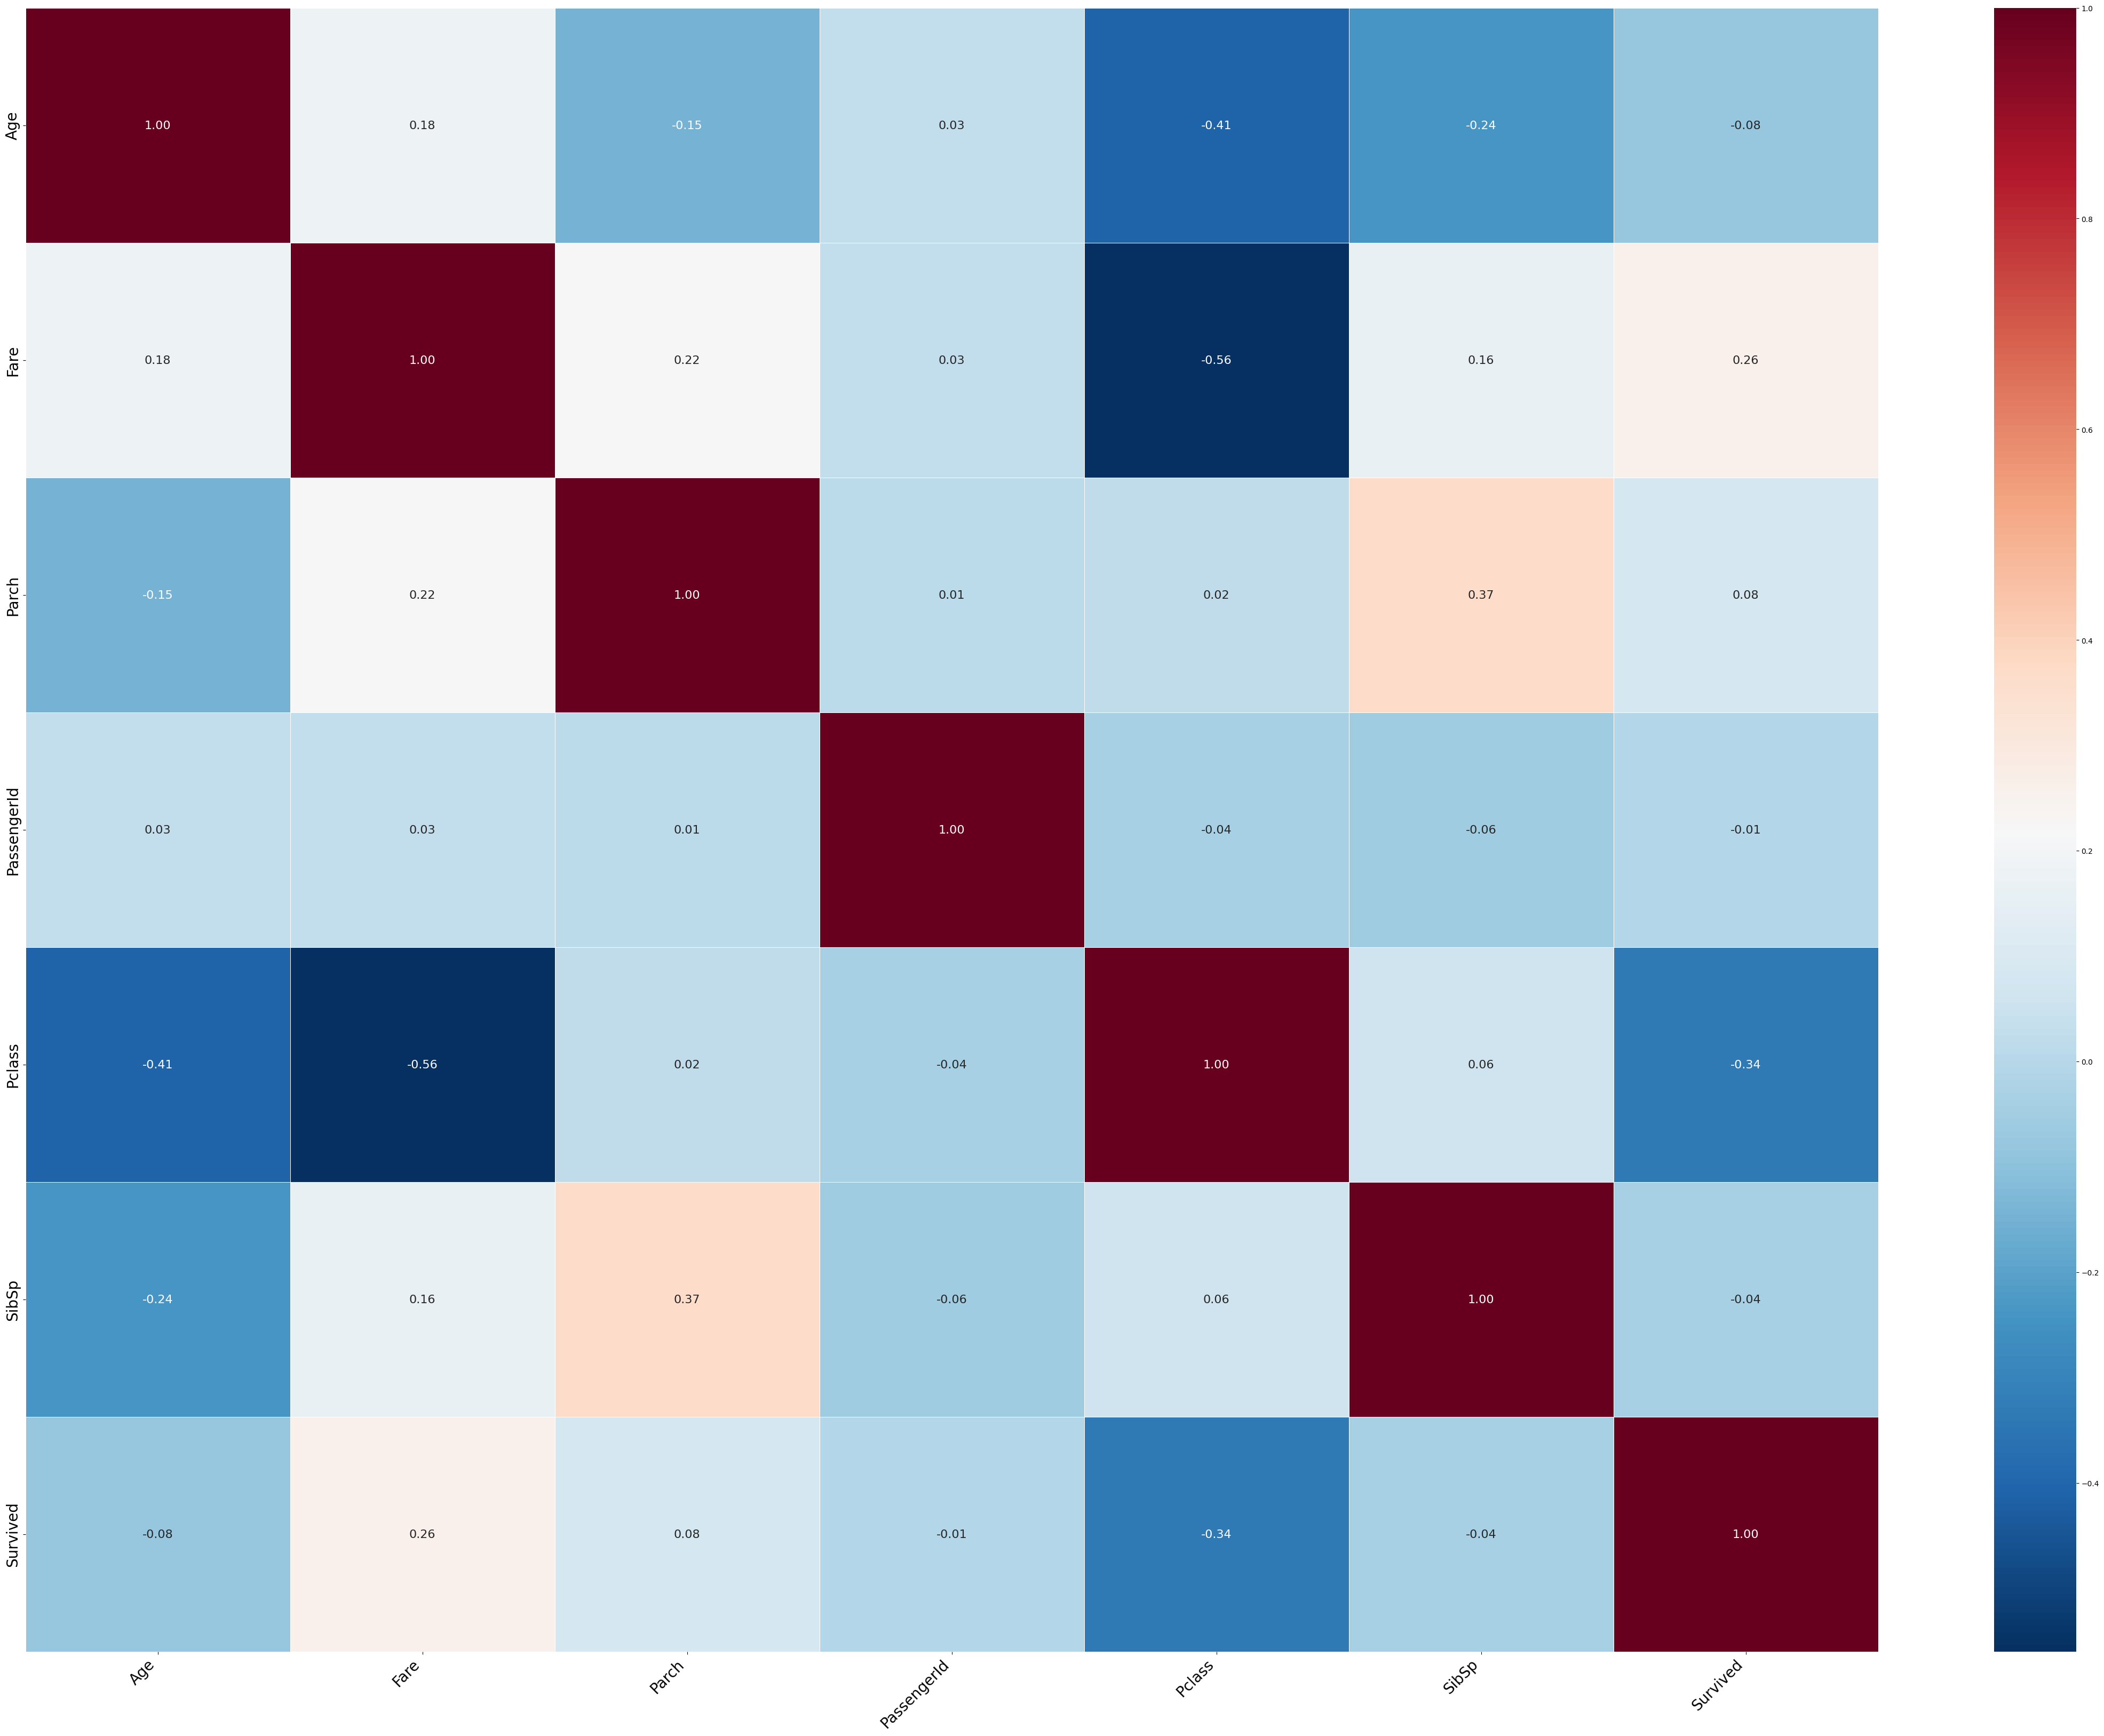

In [24]:
# Look up correlation between numeric features

# Select only numeric columns for calculating the correlation matrix
numeric_df = all_data.select_dtypes(include='number')

# Calculate the correlation matrix
df_corr = numeric_df.corr().round(2)

# Create a heatmap
plt.figure(figsize=(56, 40))
ax = sns.heatmap(
    df_corr,
    annot=True,
    cmap="RdBu_r",
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 16}   # 🔹 numbers inside cells
)

# 🔹 axis tick labels
ax.set_xticklabels(ax.get_xticklabels(), fontsize=20, rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), fontsize=20)


plt.show()

In [25]:
all_data.drop("Cabin", axis=1, inplace=True)
all_data.drop("PassengerId", axis =1, inplace = True)
all_data.drop("Name", axis=1, inplace= True)
all_data.drop("Ticket", axis =1, inplace =True)

In [26]:
all_data.head()

,Age,Embarked,Fare,Parch,Pclass,Sex,SibSp,Survived
0,22.0,S,7.2500,0,3,male,1,0.0
1,38.0,C,71.2833,0,1,female,1,1.0
2,26.0,S,7.9250,0,3,female,0,1.0
3,35.0,S,53.1000,0,1,female,1,1.0
4,35.0,S,8.0500,0,3,male,0,0.0


In [27]:
all_data["Age"] = all_data["Age"].fillna(all_data["Age"].median())

In [28]:
all_data["Embarked"] = all_data["Embarked"].fillna(all_data["Embarked"].mode()[0])


In [29]:
sample = pd.get_dummies(all_data, drop_first=True)

In [30]:
sample

,Age,Fare,Parch,Pclass,SibSp,Survived,Embarked_Q,Embarked_S,Sex_male
0,22.0,7.2500,0,3,1,0.0,False,True,True
1,38.0,71.2833,0,1,1,1.0,False,False,False
2,26.0,7.9250,0,3,0,1.0,False,True,False
3,35.0,53.1000,0,1,1,1.0,False,True,False
4,35.0,8.0500,0,3,0,0.0,False,True,True
...,...,...,...,...,...,...,...,...,...
1304,28.0,8.0500,0,3,0,NaN,False,True,True
1305,39.0,108.9000,0,1,0,NaN,False,False,False
1306,38.5,7.2500,0,3,0,NaN,False,True,True
1307,28.0,8.0500,0,3,0,NaN,False,True,True


In [31]:
train_data, test_data = divide_df(all_data, train_len)

In [32]:
train_data

,Age,Embarked,Fare,Parch,Pclass,Sex,SibSp,Survived
0,22.0,S,7.2500,0,3,male,1,0.0
1,38.0,C,71.2833,0,1,female,1,1.0
2,26.0,S,7.9250,0,3,female,0,1.0
3,35.0,S,53.1000,0,1,female,1,1.0
4,35.0,S,8.0500,0,3,male,0,0.0
...,...,...,...,...,...,...,...,...
886,27.0,S,13.0000,0,2,male,0,0.0
887,19.0,S,30.0000,0,1,female,0,1.0
888,28.0,S,23.4500,2,3,female,1,0.0
889,26.0,C,30.0000,0,1,male,0,1.0


In [33]:
# feature
X = train_data.drop("Survived", axis=1).copy()

# target
y = train_data["Survived"].copy()

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [35]:
X_train

,Age,Embarked,Fare,Parch,Pclass,Sex,SibSp
692,28.0,S,56.4958,0,3,male,0
481,28.0,S,0.0000,0,2,male,0
527,28.0,S,221.7792,0,1,male,0
855,18.0,S,9.3500,1,3,female,0
801,31.0,S,26.2500,1,2,female,1
...,...,...,...,...,...,...,...
359,28.0,Q,7.8792,0,3,female,0
258,35.0,C,512.3292,0,1,female,0
736,48.0,S,34.3750,3,3,female,1
462,47.0,S,38.5000,0,1,male,0


In [36]:
numeric_features = ["Age", "Fare"]
categorical_features = ["Sex", "Embarked", "Pclass", "SibSp", "Parch"]

# Numeric pipeline (Impute + Scale)
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline (Impute + OneHot)
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

# Combine
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

# Final pipeline with model
pipeline = Pipeline([
    ("preprocessing", preprocessor),
])

In [37]:
def objective(trial, model_name):

    if model_name == "rf":
        model = RandomForestClassifier(
            n_estimators=trial.suggest_int("n_estimators", 100, 500),
            max_depth=trial.suggest_int("max_depth", 3, 20),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 10),
            random_state=42
        )

    elif model_name == "logreg":
        model = LogisticRegression(
            C=trial.suggest_float("C", 0.001, 10.0, log=True),
            solver="liblinear",
            max_iter=1000
        )

    elif model_name == "xgb":
        model = XGBClassifier(
            n_estimators=trial.suggest_int("n_estimators", 200, 1000),
            max_depth=trial.suggest_int("max_depth", 3, 10),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3),
            subsample=trial.suggest_float("subsample", 0.5, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
            eval_metric="logloss",
            random_state=42,
            early_stopping_rounds=50

        )

    # 🔹 Preprocessing
    X_tr_processed = preprocessor.fit_transform(X_train)
    X_val_processed = preprocessor.transform(X_test)

    # 🔹 Special case for XGBoost
    if model_name == "xgb":
        model.fit(
            X_tr_processed,
            y_train,
            eval_set=[(X_val_processed, y_test)],
            
            verbose=False
        )
    else:
        model.fit(X_tr_processed, y_train)

    preds = model.predict(X_val_processed)

    acc = accuracy_score(y_test, preds)

    return acc

In [38]:
study = optuna.create_study(direction="maximize")

study.optimize(
    lambda trial: objective(trial, "rf"),
    n_trials=30
)

print("Best params:", study.best_params)
print("Best CV Accuracy:", study.best_value)

[I 2026-03-05 12:08:58,666] A new study created in memory with name: no-name-0e9c75e5-7571-46c2-8a8e-e9ebfbba6d5b
[I 2026-03-05 12:08:59,372] Trial 0 finished with value: 0.8156424581005587 and parameters: {'n_estimators': 459, 'max_depth': 15, 'min_samples_split': 8}. Best is trial 0 with value: 0.8156424581005587.
[I 2026-03-05 12:09:00,097] Trial 1 finished with value: 0.8100558659217877 and parameters: {'n_estimators': 435, 'max_depth': 20, 'min_samples_split': 6}. Best is trial 0 with value: 0.8156424581005587.
[I 2026-03-05 12:09:00,473] Trial 2 finished with value: 0.8156424581005587 and parameters: {'n_estimators': 220, 'max_depth': 15, 'min_samples_split': 3}. Best is trial 0 with value: 0.8156424581005587.
[I 2026-03-05 12:09:00,868] Trial 3 finished with value: 0.7988826815642458 and parameters: {'n_estimators': 277, 'max_depth': 10, 'min_samples_split': 7}. Best is trial 0 with value: 0.8156424581005587.
[I 2026-03-05 12:09:01,535] Trial 4 finished with value: 0.82122905027

Best params: {'n_estimators': 454, 'max_depth': 17, 'min_samples_split': 2}
Best CV Accuracy: 0.8324022346368715


In [39]:
print(study.best_value)

0.8324022346368715


In [40]:
study_log = optuna.create_study(direction="maximize")
study_log.optimize(lambda trial: objective(trial, "logreg"), n_trials=30)

print("Best params:", study_log.best_params)
print("Best CV Accuracy:", study_log.best_value)

[I 2026-03-05 12:09:23,196] A new study created in memory with name: no-name-86fe5e77-2857-4b23-80cf-6983fbfca387
[I 2026-03-05 12:09:23,214] Trial 0 finished with value: 0.770949720670391 and parameters: {'C': 0.03970917105424667}. Best is trial 0 with value: 0.770949720670391.
[I 2026-03-05 12:09:23,230] Trial 1 finished with value: 0.770949720670391 and parameters: {'C': 0.03194872270412149}. Best is trial 0 with value: 0.770949720670391.
[I 2026-03-05 12:09:23,246] Trial 2 finished with value: 0.7932960893854749 and parameters: {'C': 0.1309380709489322}. Best is trial 2 with value: 0.7932960893854749.
[I 2026-03-05 12:09:23,259] Trial 3 finished with value: 0.8100558659217877 and parameters: {'C': 9.20671890556847}. Best is trial 3 with value: 0.8100558659217877.
[I 2026-03-05 12:09:23,271] Trial 4 finished with value: 0.770949720670391 and parameters: {'C': 0.03574104407948766}. Best is trial 3 with value: 0.8100558659217877.
[I 2026-03-05 12:09:23,285] Trial 5 finished with value

Best params: {'C': 0.6211226840649949}
Best CV Accuracy: 0.8156424581005587


In [41]:
study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(lambda trial: objective(trial, "xgb"), n_trials=30)
print("Best params:", study_xgb.best_params)
print("Best CV Accuracy:", study_xgb.best_value)

[I 2026-03-05 12:09:26,820] A new study created in memory with name: no-name-a46b93aa-9ba2-48e8-9611-b15ce95f6555
[I 2026-03-05 12:09:27,018] Trial 0 finished with value: 0.8100558659217877 and parameters: {'n_estimators': 743, 'max_depth': 9, 'learning_rate': 0.18351383695476792, 'subsample': 0.8717915759516875, 'colsample_bytree': 0.5563605032563341}. Best is trial 0 with value: 0.8100558659217877.
[I 2026-03-05 12:09:27,100] Trial 1 finished with value: 0.7988826815642458 and parameters: {'n_estimators': 462, 'max_depth': 7, 'learning_rate': 0.09672564282845841, 'subsample': 0.5457087949234589, 'colsample_bytree': 0.5674866743585305}. Best is trial 0 with value: 0.8100558659217877.
[I 2026-03-05 12:09:27,197] Trial 2 finished with value: 0.7988826815642458 and parameters: {'n_estimators': 282, 'max_depth': 5, 'learning_rate': 0.03257752418616549, 'subsample': 0.950380153460842, 'colsample_bytree': 0.604451873655204}. Best is trial 0 with value: 0.8100558659217877.
[I 2026-03-05 12:0

Best params: {'n_estimators': 976, 'max_depth': 10, 'learning_rate': 0.05676316525095271, 'subsample': 0.582114354405248, 'colsample_bytree': 0.503005732415869}
Best CV Accuracy: 0.8268156424581006


# Final Model Training

In [42]:
best_params = study_xgb.best_params

final_xgb = XGBClassifier(
    **best_params,
    eval_metric="logloss",
    early_stopping_rounds=50,
    random_state=42
)

In [43]:
X_tr_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_test)

In [44]:
final_xgb.fit(
    X_tr_processed,
    y_train,
    eval_set=[(X_val_processed, y_test)],
    verbose=False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.503005732415869
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import loa

In [45]:
test_data

,Age,Embarked,Fare,Parch,Pclass,Sex,SibSp
891,34.5,Q,7.8292,0,3,male,0
892,47.0,S,7.0000,0,3,female,1
893,62.0,Q,9.6875,0,2,male,0
894,27.0,S,8.6625,0,3,male,0
895,22.0,S,12.2875,1,3,female,1
...,...,...,...,...,...,...,...
1304,28.0,S,8.0500,0,3,male,0
1305,39.0,C,108.9000,0,1,female,0
1306,38.5,S,7.2500,0,3,male,0
1307,28.0,S,8.0500,0,3,male,0


In [46]:
test_recs = preprocessor.transform(test_data)

c:\Users\keith\implementations\TitanicMLCICD\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [47]:
##Seen data predictions
from sklearn.metrics import accuracy_score

preds = final_xgb.predict(X_val_processed)
acc = accuracy_score(y_test, preds)

print("Final Validation Accuracy:", acc)

Final Validation Accuracy: 0.8268156424581006


In [48]:
##unseen data predictions

y_preds_df = pd.read_csv(os.path.join(data_dir, "gender_submission.csv"))

survived_list = y_preds_df["Survived"].tolist()

print(survived_list)

[0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 

In [49]:
y_preds = final_xgb.predict(test_recs)
acc = accuracy_score(survived_list, y_preds)

print("Final Validation Accuracy:", acc)

Final Validation Accuracy: 0.8708133971291866


In [52]:
print(y_preds)

[0 0 0 0 0 0 1 0 1 0 0 0 1 0 1 1 0 0 0 1 0 0 1 1 1 0 1 0 1 0 0 0 0 0 1 0 0
 0 0 1 0 1 0 1 1 0 0 0 1 1 0 0 1 1 0 0 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 0 0 0
 1 1 0 1 0 1 1 0 0 0 0 0 1 0 1 1 0 0 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 0 0 0 0
 1 1 1 1 0 0 1 0 1 1 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0
 1 0 1 0 0 1 0 0 1 1 1 1 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 1 1 1 1 0 1 1 0 1
 0 1 0 0 0 0 0 0 0 0 0 1 1 0 0 1 1 0 1 0 0 1 0 1 0 0 0 0 1 0 0 1 0 1 0 1 0
 1 0 1 0 0 1 0 0 0 1 0 0 1 0 0 0 1 1 1 1 1 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 1
 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0
 1 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 0 1 0 0 0 1 0 0
 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 1 0 0 0 1 0 1 0 0 0 0 1 1 0 1 0 0 0 1 0
 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1 0 0 0 0
 0 1 1 1 1 0 0 1 0 0 0]


In [51]:
import joblib
import os

# Create folder if it doesn't exist
os.makedirs("../artifacts", exist_ok=True)

# Save model
joblib.dump(final_xgb, "../artifacts/model.pkl")

# Save preprocessing pipeline
joblib.dump(preprocessor, "../artifacts/preprocessor.pkl")

['../artifacts/preprocessor.pkl']

In [ ]:


# Save model
joblib.dump(final_xgb, "../models/best_xgb.pkl")

NameError: name 'final_xgb' is not defined